# 🧪 PyTorch Lab 6: RNN

# 1. Exploratory Data Analysis

We will generate a dataset for forecasting using RNN.

In [10]:
import numpy as np
import matplotlib.pyplot as plt

In [11]:
# Generate a sine wave dataset
def generate_data(seq_length, num_samples):
    x = np.linspace(0, 100, num_samples)
    data = np.sin(x)
    sequences = []
    targets = []
    for i in range(len(data) - seq_length):
        sequences.append(data[i:i + seq_length])
        targets.append(data[i + seq_length])
    return np.array(sequences), np.array(targets)

**Exercise** Explain with word what this function does.

This function creates a simple dataset for sequence prediction using a sine wave.
It generate ``num_samples - seq_length`` sequences with each of length ``seq_length``

**Exercise** Use this function to generate 1000 sequences of size 30.


In [12]:
SEQ_LENGTH = 30
NUM_SAMPLES = 1030

X, y = generate_data(SEQ_LENGTH, NUM_SAMPLES)

**Exercise** Plot several sequences with the target

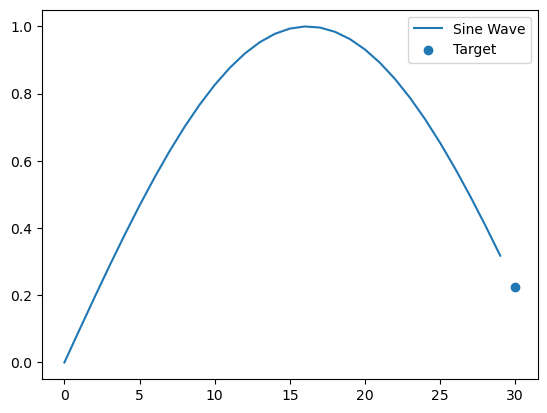

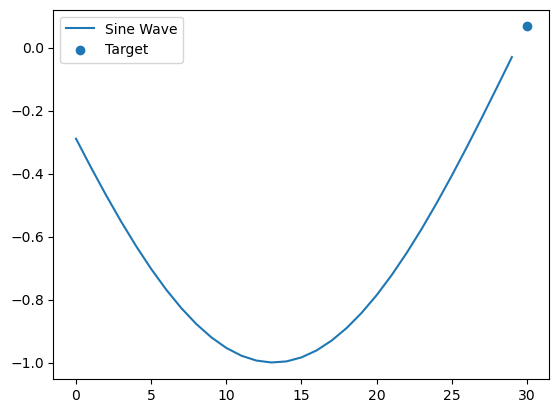

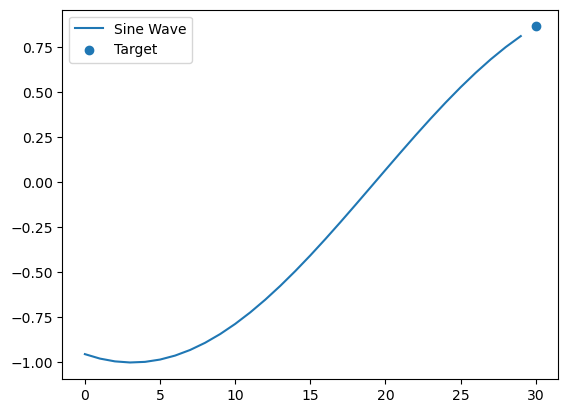

In [13]:
for i in [0,100,110]:
  xis = np.arange(len(X[i])+1)
  # Plot the dataset
  plt.plot(xis[:-1], X[i], label='Sine Wave')
  plt.scatter(xis[-1], y[i], label='Target')
  plt.legend()
  plt.show()

# 2. Forecasting with a simple MLP

First, we will use a simple multi layer perceptron to try to predict the y values, as we always do we put the data in a dataset and split using a dataloader

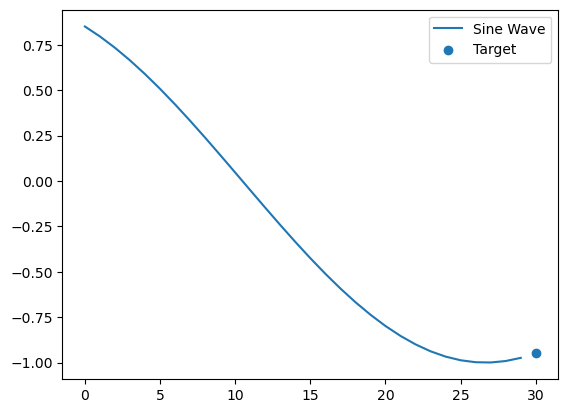

In [14]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# Define a PyTorch Dataset
class RegressionDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create PyTorch Datasets
train_dataset = RegressionDataset(X_train, y_train)
test_dataset = RegressionDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

for inputs, target in train_loader:
  xis = np.arange(len(inputs[0])+1)
  plt.plot(xis[:-1], inputs[0], label='Sine Wave')
  plt.scatter(xis[-1], target[0], label='Target')
  plt.legend()
  plt.show()
  break


**Exercise** Explain what is the task, including the dimension of input and output

The task is a sequence-to-one regression task. The goal is:
- Input: a short sequence of sine wave values
- Output: the next sine wave value after that sequence
  
So the model is learning next-step prediction.
  
- Input dimension: ``(num_samples - seq_length, seq_length)``
- Output dimension: ``(num_samples - seq_length,)``

**Exercise** Complete the code such that it runs smoothly (replace the ...)

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Define the MLP model
class SimpleMLP(nn.Module):
    def __init__(self):
        super(SimpleMLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(30, 64),  # First layer
            nn.ReLU(),                # Activation
            nn.Linear(64, 32),        # Second layer
            nn.ReLU(),                # Activation
            nn.Linear(32, 1) # Output layer
        )

    def forward(self, x):
        return self.model(x).squeeze()

model = SimpleMLP()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    loss_epoch = 0
    for batch_idx, (inputs, targets) in enumerate(train_loader):

        outputs = model(inputs)

        loss = criterion(outputs, targets)
        loss_epoch += loss.item()


        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        loss_epoch += loss.item()
    if epoch % 1 == 0:
        model.eval()
        loss_test = 0
        for batch_idx, (inputs, targets) in enumerate(test_loader):

          outputs = model(inputs)
          loss = criterion(outputs, targets)
          loss_test += loss.item()
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss train: {loss_epoch:.4f}, Loss test: {loss_test:.4f}")


Epoch [1/10], Loss train: 10.5296, Loss test: 0.1741
Epoch [2/10], Loss train: 0.4953, Loss test: 0.0140
Epoch [3/10], Loss train: 0.0758, Loss test: 0.0029
Epoch [4/10], Loss train: 0.0074, Loss test: 0.0003
Epoch [5/10], Loss train: 0.0016, Loss test: 0.0001
Epoch [6/10], Loss train: 0.0007, Loss test: 0.0001
Epoch [7/10], Loss train: 0.0006, Loss test: 0.0001
Epoch [8/10], Loss train: 0.0004, Loss test: 0.0000
Epoch [9/10], Loss train: 0.0004, Loss test: 0.0000
Epoch [10/10], Loss train: 0.0003, Loss test: 0.0000


# 2. Forecasting with an RNN

Now we will use an RNN. We propose an implementaiton of a simple RNN.

**Exercise** Explain below why the input dimension of the RNN layer is 1 ?

In this setup, the input dimension of the RNN layer is 1 because each time step contains only one feature.

Here is the key idea:

- The sequence has length  ``seq_length``
- At each position in that sequence, the value is just one sine number
- 
So for the RNN, each time step receives a single scalar

**Exercise** Run the follwoing and explain line a, b and c below. Use [pytorch documentation](https://pytorch.org/docs/stable/generated/torch.nn.RNN.html):

In [16]:
import torch.nn as nn

class RNNModel(nn.Module):
    def __init__(self, hidden_size=256, num_layers=3):
        super(RNNModel, self).__init__()
        self.rnn = nn.RNN(1, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size,1)

    def forward(self, x):
        out, h = self.rnn(x) #out contains the output at each step, h is the final hidden state for each sequence
        # print(out.shape, h.shape)
        out = self.fc(out[:, -1, :])
        return out.squeeze()

model = RNNModel()

X_temp, _ = next(iter(train_loader)) #Line a
X_temp = X_temp.unsqueeze(-1) #Line b
model(X_temp) #Line c

tensor([0.0847, 0.0847, 0.0846, 0.0842, 0.0847, 0.0846, 0.0842, 0.0841, 0.0847,
        0.0846, 0.0839, 0.0841, 0.0842, 0.0843, 0.0842, 0.0846, 0.0840, 0.0847,
        0.0847, 0.0839, 0.0843, 0.0847, 0.0843, 0.0843, 0.0844, 0.0841, 0.0837,
        0.0844, 0.0847, 0.0842, 0.0840, 0.0844], grad_fn=<SqueezeBackward0>)

# It's training time ^^

In [17]:
model = RNNModel()
riterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10
for epoch in range(num_epochs):
    loss_epoch = 0
    for seq, target in train_loader:
        seq = seq.unsqueeze(-1)  # Add feature dimension
        output = model(seq)
        loss = criterion(output, target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_epoch += loss.item()
    # print(f"Output shape: {output.shape}, Target shape: {target.shape}")
    if epoch % 1 == 0:
        model.eval()
        loss_test = 0
        for seq, target in test_loader:
          seq = seq.unsqueeze(-1)  # Add feature dimension
          output = model(seq)
          loss = criterion(output, target)
          loss_test += loss.item()
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss train: {loss_epoch:.4f}, Loss test: {loss_test:.4f}")

Epoch [1/10], Loss train: 2.2878, Loss test: 0.0823
Epoch [2/10], Loss train: 0.0867, Loss test: 0.0016
Epoch [3/10], Loss train: 0.0055, Loss test: 0.0003
Epoch [4/10], Loss train: 0.0013, Loss test: 0.0002
Epoch [5/10], Loss train: 0.0018, Loss test: 0.0002
Epoch [6/10], Loss train: 0.0010, Loss test: 0.0002
Epoch [7/10], Loss train: 0.0008, Loss test: 0.0003
Epoch [8/10], Loss train: 0.0010, Loss test: 0.0005
Epoch [9/10], Loss train: 0.0010, Loss test: 0.0002
Epoch [10/10], Loss train: 0.0017, Loss test: 0.0002


# 3. Doing next time step prediciton in an autoregressive way

Now, we switch paradigme, and instead of using 30 time step to predict the 31st, we to $x_{0:t}$ to $x_{t+1}$. It is easy to implement.

In [18]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

# 1. Generate autoregressive dataset: x_{0:t} -> x_{t+1}
def generate_autoregressive_data(num_samples):
    x = np.linspace(0, 100, num_samples)
    data = np.sin(x).astype(np.float32)

    sequences = []
    targets = []

    for t in range(num_samples - 1):
        sequences.append(data[:t + 1])   # prefix: x_{0:t}
        targets.append(data[t + 1])      # next value: x_{t+1}

    return sequences, np.array(targets, dtype=np.float32)


# 2. Dataset
class PrefixDataset(Dataset):
    def __init__(self, sequences, targets):
        self.sequences = [torch.tensor(seq, dtype=torch.float32) for seq in sequences]
        self.targets = torch.tensor(targets, dtype=torch.float32)

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        return self.sequences[idx], self.targets[idx]


# 3. Collate function for padding variable-length sequences
def collate_fn(batch):
    sequences, targets = zip(*batch)

    lengths = torch.tensor([len(seq) for seq in sequences], dtype=torch.long)
    padded_sequences = pad_sequence(sequences, batch_first=True)   # (batch, max_len)
    targets = torch.stack(targets)                          # (batch,)

    return padded_sequences, lengths, targets


# 4. RNN model
class RNNModel(nn.Module):
    def __init__(self, hidden_size=256, num_layers=3):
        super(RNNModel, self).__init__()
        self.rnn = nn.RNN(input_size=1, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x, lengths):
        # x: (batch, seq_len, 1)
        out, h = self.rnn(x)   # out: (batch, seq_len, hidden_size)

        # Take the last valid output for each sequence
        idx = (lengths - 1).to(x.device)
        out_last = out[torch.arange(x.size(0), device=x.device), idx, :]   # (batch, hidden_size)

        out = self.fc(out_last)   # (batch, 1)
        return out.squeeze(-1)    # (batch,)


# 5. Build data
num_samples = 1000
sequences, targets = generate_autoregressive_data(num_samples)

split = int(0.8 * len(sequences))
train_sequences, test_sequences = sequences[:split], sequences[split:]
train_targets, test_targets = targets[:split], targets[split:]

train_dataset = PrefixDataset(train_sequences, train_targets)
test_dataset = PrefixDataset(test_sequences, test_targets)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)


# 6. Train
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = RNNModel().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    loss_epoch = 0.0

    for seq, lengths, target in train_loader:
        seq = seq.unsqueeze(-1).to(device)     # (batch, seq_len, 1)
        lengths = lengths.to(device)
        target = target.to(device)

        output = model(seq, lengths)
        loss = criterion(output, target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_epoch += loss.item()

    model.eval()
    loss_test = 0.0
    with torch.no_grad():
        for seq, lengths, target in test_loader:
            seq = seq.unsqueeze(-1).to(device)
            lengths = lengths.to(device)
            target = target.to(device)

            output = model(seq, lengths)
            loss = criterion(output, target)
            loss_test += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss train: {loss_epoch:.4f}, Loss test: {loss_test:.4f}")


# 7. Autoregressive forecasting
def autoregressive_forecast(model, init_sequence, future_steps, device):
    model.eval()

    seq = torch.tensor(init_sequence, dtype=torch.float32).unsqueeze(0).to(device)  # (1, seq_len)
    predictions = []

    with torch.no_grad():
        for _ in range(future_steps):
            lengths = torch.tensor([seq.size(1)], dtype=torch.long).to(device)
            x = seq.unsqueeze(-1)   # (1, seq_len, 1)

            next_value = model(x, lengths).item()
            predictions.append(next_value)

            next_tensor = torch.tensor([[next_value]], dtype=torch.float32).to(device)
            seq = torch.cat([seq, next_tensor], dim=1)

    return predictions


# 8. Example prediction
init_sequence = np.sin(np.linspace(0, 2, 20)).astype(np.float32)
future_steps = 10
future_preds = autoregressive_forecast(model, init_sequence, future_steps, device)

print("\nInitial sequence:")
print(init_sequence)

print("\nFuture predictions:")
print(future_preds)

Epoch [1/10], Loss train: 1.3715, Loss test: 0.0602
Epoch [2/10], Loss train: 0.0539, Loss test: 0.0034
Epoch [3/10], Loss train: 0.0078, Loss test: 0.0006
Epoch [4/10], Loss train: 0.0020, Loss test: 0.0008
Epoch [5/10], Loss train: 0.0010, Loss test: 0.0003
Epoch [6/10], Loss train: 0.0007, Loss test: 0.0001
Epoch [7/10], Loss train: 0.0005, Loss test: 0.0001
Epoch [8/10], Loss train: 0.0004, Loss test: 0.0001
Epoch [9/10], Loss train: 0.0004, Loss test: 0.0002
Epoch [10/10], Loss train: 0.0009, Loss test: 0.0005

Initial sequence:
[0.         0.10506888 0.20897463 0.310567   0.4087214  0.50235116
 0.5904198  0.67195255 0.74604666 0.81188196 0.8687296  0.9159604
 0.9530513  0.9795919  0.9952883  0.9999668  0.9935755  0.97618526
 0.9479885  0.9092974 ]

Future predictions:
[0.873690128326416, 0.8248574733734131, 0.7780417203903198, 0.7328670620918274, 0.6887427568435669, 0.6467787027359009, 0.6082665920257568, 0.5738357305526733, 0.5433907508850098, 0.5169881582260132]


**Exercise** Spot the differences and explain what is happening here.

This is still a standard RNN; the main difference is in how the training data is formed. Before, each sample used a fixed-length window of 30 steps to predict step 31, while here each sample uses the entire variable-length prefix $x_{0:t}$ to predict the next value $x_{t+1}$, so padding and sequence lengths are needed.